# Addressing Bias and Fairness in Machine Learning Models

# Intro to Fairness: Income Prediction



This notebook is a practical equivalent of Google's ML Crash Course fairness exercise - due to dependency hell with TFDV pkg on windows i had to use a separate pkg from microsoft (fairlearn).

Here, I will:

1. **Explore** the Adult Census Income dataset and identify potential sources of bias
2. **Train** a baseline classifier to predict whether income exceeds $50K/year
3. **Evaluate** overall model performance
4. **Audit** fairness: evaluate performance *by subgroup* (gender, race)
5. **Mitigate** bias using Fairlearn's algorithms
6. **Compare** the fairness-aware model against the baseline

---

### Dataset: Adult Census Income
The dataset is derived from 1994 US Census data. The prediction task is:
> *Given demographic and employment information about a person, predict whether their annual income exceeds $50,000.*

This is a classic fairness case study because the dataset reflects real historical biases; most high earners in the data are white males, and a model trained naively can learn and amplify these patterns.

**Features include:** age, education, occupation, marital status, race, gender, hours per week, native country.

**Sensitive attributes we'll audit:** `gender`, `race`

# To throw more light on what this notebook aims to solve:

## the real point isn't the prediction
The prediction is just the vehicle.
The actual objective is to study what happens when you train a model on real-world historical data that already contains societal inequalities, and then ask: is this model treating everyone **fairly**?
## What **fairly** means in this context
The dataset was collected in 1994, a time when women and racial minorities were systematically underrepresented in high-income brackets — not necessarily because they were less capable, but because of structural barriers in society.

When you train a model on this data, the model learns those patterns. It doesn't know or care that the patterns reflect historical injustice rather than ground truth. It just optimizes to predict the label correctly.


So the danger is: you build a model, it achieves 83% accuracy, you declare success — but underneath that score, the model is systematically underestimating the earning potential of women and certain racial groups, because that's what the training data showed.


## The three-part journey this notebook takes you through
* First, it teaches us to interrogate the data before we train anything, because bias enters at the data collection stage, not just at the modeling stage.

* Second, it shows us that overall accuracy is a fundamentally insufficient measure of a model's quality in high-stakes applications. A model that is 83% accurate overall can simultaneously be significantly less accurate for specific subgroups — and you'd never know unless you looked ( this is where it gets interesting for me )

* Third, it introduces the idea that you can actively intervene — apply constraints ( like **Demographic Parity** or **Equality of Opportunity** ) during training that force the model to equalize its behavior across groups — and then honestly examine what that costs you in overall accuracy.


## Why this matters
The Adult Census dataset is used as a proxy for real decisions: loan approvals, hiring algorithms, insurance pricing, credit scoring. A model trained on this data, deployed in production, would systematically disadvantage women and certain racial groups in financial decisions — not because anyone programmed it to discriminate, but because it faithfully learned from biased historical patterns. This is exactly the class of real-world harm that fairness-aware ML is trying to prevent.



**In this notebook, we'd be building models that are not just accurate on average, but accountable to every subgroup they make decisions about.**

This project demonstrates how to mitigate undesirable biases in a trained model. while the model and the prediction task in this notebook is not real, the emphasis here is the approach to evaluating the performance of a trained model and minimizing error rates between demographics groups.

With regard to the prediction task, there may circumstances where an individual's income may be used as a determining factor, such as obtaining a loan, acquiring insurance, applying for assistance programs, or possibly to advertise products. But in those cases, such businesses, institutions or organizations would not be looking to infer one's income using a machine learning model; they would instead obtain that information directly from the applicant, if possible, or rely on other signals to decide on the outcome.

## Setup

In [1]:
!pip install fairlearn scikit-learn pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.9 MB/s eta 0:00:00


After Installation all necessary components can now be imported — including MinDiff for addressing unfair bias in models and Fairness Indicators for evaluating and improving models for fairness concerns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    false_positive_rate,
    false_negative_rate,
    selection_rate
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer

## we load the adult census dataset directly from the UCI webpage.
it is critical to understand from the dataset, who is underrepresented or represented

In [2]:
# Column names for the dataset
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'gender',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

train_df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    names=COLUMNS, sep=r'\s*,\s*', engine='python', na_values='?'
)
test_df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',
    names=COLUMNS, sep=r'\s*,\s*', skiprows=[0], engine='python', na_values='?'
)


In [5]:
train_df.head(20)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [6]:
test_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


In [7]:
# Drop rows with missing values
train_df = train_df.dropna(how='any', axis=0)
test_df  = test_df.dropna(how='any', axis=0)

# Clean income_bracket label (test set has trailing period)
train_df['income_bracket'] = train_df['income_bracket'].str.strip()
test_df['income_bracket']  = test_df['income_bracket'].str.strip().str.rstrip('.')

# Binary label: 1 = income >50K, 0 = <=50K
train_df['label'] = (train_df['income_bracket'] == '>50K').astype(int)
test_df['label']  = (test_df['income_bracket']  == '>50K').astype(int)

print(f'Train set: {train_df.shape[0]:,} rows')
print(f'Test set:  {test_df.shape[0]:,} rows')
train_df.head()

Train set: 30,162 rows
Test set:  15,060 rows


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket,label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## Class Distribution

The first thing to check is whether the dataset is balanced. An imbalanced label distribution means a naive model could appear "accurate" just by predicting the majority class.

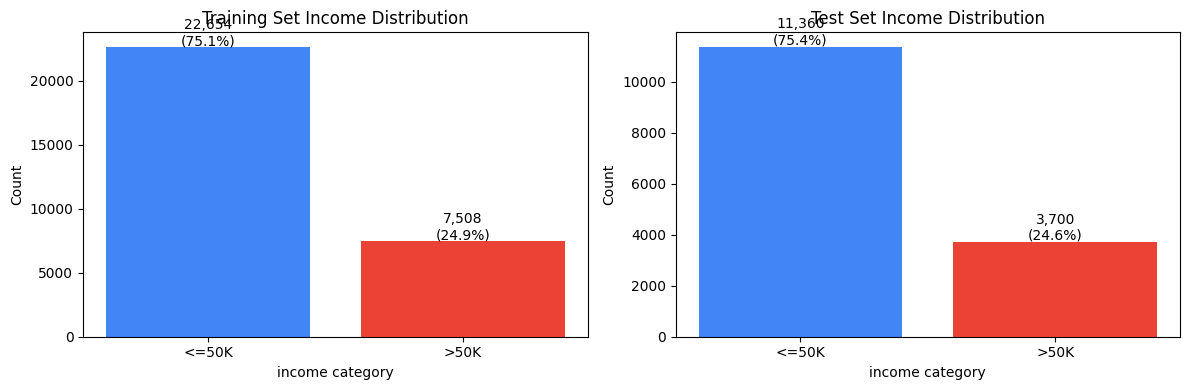


Note: The dataset is Imbalanced; ~75% earn <= 50K. Accuracy alone is misleading


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training Set', 'Test Set']):
  counts = df['income_bracket'].value_counts()
  ax.bar(counts.index, counts.values, color = ['#4285F4', '#EA4335'])
  ax.set_title(f'{title} Income Distribution')
  ax.set_ylabel('Count')
  ax.set_xlabel('income category')
  for i, (label, count) in enumerate(counts.items()):
    ax.text(i, count + 100, f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=10)


plt.tight_layout()
plt.show()
print('\nNote: The dataset is Imbalanced; ~75% earn <= 50K.',
      'Accuracy alone is misleading')

## Explore Sensitive Attributes

> **Key question:** Are gender and race represented proportionally in the high-income group?

If not, a model trained on this data may learn to associate those demographics with lower income even if those features shouldn't influence the prediction.

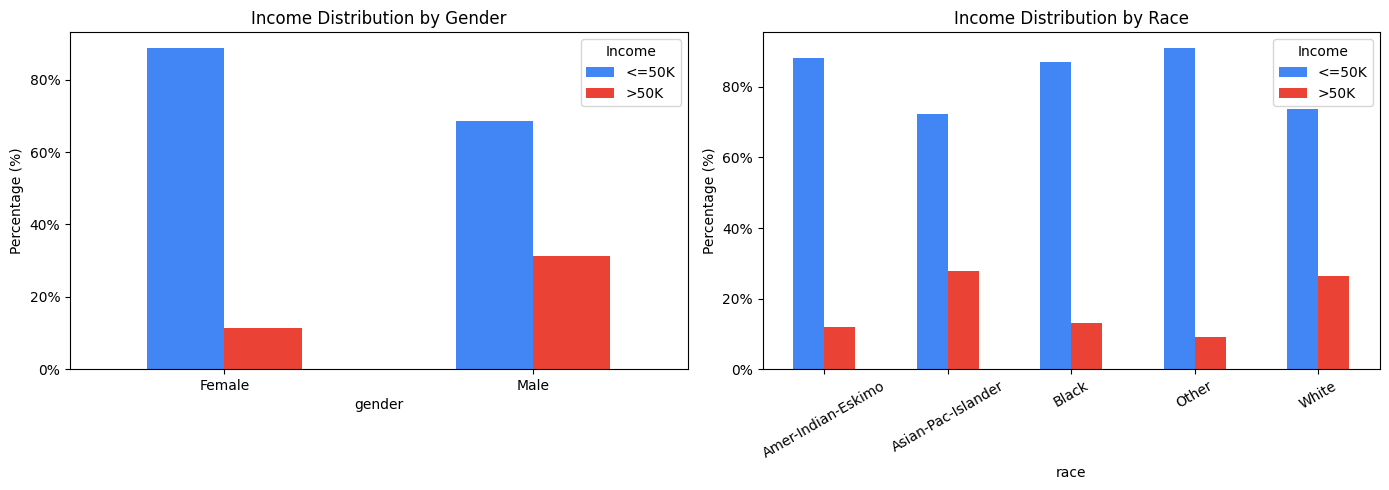

||High Income Rate (>50K) by Gender||
gender
Female    11.4%
Male      31.4%
Name: label, dtype: object

||High Income Rate (>50K) by Race||
race
Amer-Indian-Eskimo    11.9%
Asian-Pac-Islander    27.7%
Black                 13.0%
Other                  9.1%
White                 26.4%
Name: label, dtype: object


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender vs income
gender_income = train_df.groupby(['gender', 'income_bracket']).size().unstack(fill_value=0)
gender_pct = gender_income.div(gender_income.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[0], color=['#4285F4', '#EA4335'], rot=0)
axes[0].set_title('Income Distribution by Gender')
axes[0].set_ylabel('Percentage (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='Income')

# Race vs income
race_income = train_df.groupby(['race', 'income_bracket']).size().unstack(fill_value=0)
race_pct = race_income.div(race_income.sum(axis=1), axis=0) * 100
race_pct.plot(kind='bar', ax=axes[1], color=['#4285F4', '#EA4335'], rot=30)
axes[1].set_title('Income Distribution by Race')
axes[1].set_ylabel('Percentage (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title='Income')

plt.tight_layout()
plt.show()

# Print exact rates
print('||High Income Rate (>50K) by Gender||')
print(train_df.groupby('gender')['label'].mean().map('{:.1%}'.format))
print('\n||High Income Rate (>50K) by Race||')
print(train_df.groupby('race')['label'].mean().map('{:.1%}'.format))

## Education vs Income

Education is highly correlated with income. This is fine as a feature but if education access itself is correlated with race or gender (which historically it is), the model can indirectly encode demographic bias.

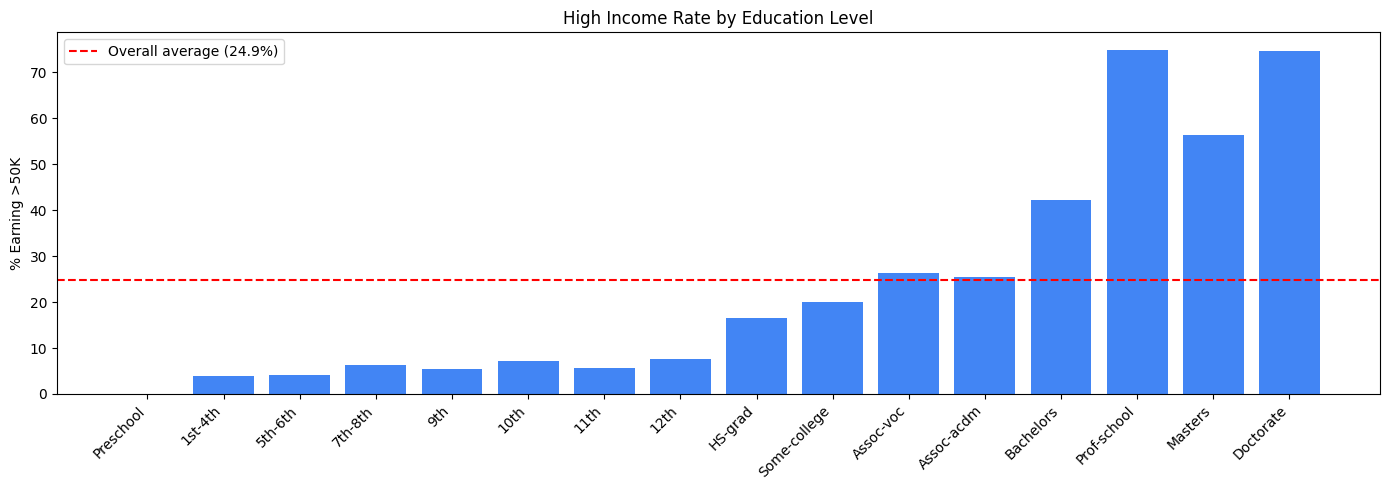

In [15]:
edu_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th',
    '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc',
    'Assoc-acdm', 'Bachelors', 'Prof-school', 'Masters', 'Doctorate'
]

edu_rate = train_df.groupby('education')['label'].mean().reindex(edu_order).dropna()

plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(edu_rate)), edu_rate.values * 100, color='#4285F4')
plt.xticks(range(len(edu_rate)), edu_rate.index, rotation=45, ha='right')
plt.ylabel('% Earning >50K')
plt.title('High Income Rate by Education Level')
plt.axhline(y=train_df['label'].mean()*100, color='red',
            linestyle='--', label=f'Overall average ({train_df["label"].mean():.1%})')
plt.legend()
plt.tight_layout()
plt.show()

# Prepare Features and Train a Baseline Model

We train a Logistic Regression model using both numerical and categorical features. This is our **baseline** trained without any fairness constraints.

In [16]:
# Feature selection

NUMERIC_FEATURES = ['age', 'education_num', 'capital_gain',
                    'capital_loss', 'hours_per_week', 'fnlwgt']
CATEGORICAL_FEATURES = ['workclass', 'marital_status', 'occupation',
                        'relationship', 'native_country']
# NOTE: We intentionally exclude 'gender' and 'race' as direct input features.
# A fair model should not use protected attributes as predictors.
# (In practice they can still leak in through proxies like 'relationship'.)

def preprocess(df, fit_encoders=None):
    X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
    encoders = fit_encoders or {}
    for col in CATEGORICAL_FEATURES:
        if col not in encoders:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders[col] = le
        else:
            le = encoders[col]
            X[col] = X[col].astype(str).map(
                lambda s, le=le: le.transform([s])[0]
                if s in le.classes_ else -1
            )
    return X, encoders

X_train, encoders = preprocess(train_df)
X_test, _         = preprocess(test_df, fit_encoders=encoders)
y_train = train_df['label'].values
y_test  = test_df['label'].values

# Sensitive attribute arrays (for fairness evaluation)
gender_train = train_df['gender'].values
gender_test  = test_df['gender'].values
race_train   = train_df['race'].values
race_test    = test_df['race'].values

# Train baseline model
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

print('Baseline model trained.')
print(f'Overall Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Overall AUC:      {roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:,1]):.4f}')

Baseline model trained.
Overall Accuracy: 0.8181
Overall AUC:      0.8428


##  Evaluate Overall Performance

Overall accuracy and AUC look reasonable. But **overall metrics hide a lot** a model can perform well on average while systematically failing specific subgroups.

=== Classification Report (Overall) ===
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89     11360
        >50K       0.70      0.45      0.55      3700

    accuracy                           0.82     15060
   macro avg       0.77      0.69      0.72     15060
weighted avg       0.81      0.82      0.80     15060



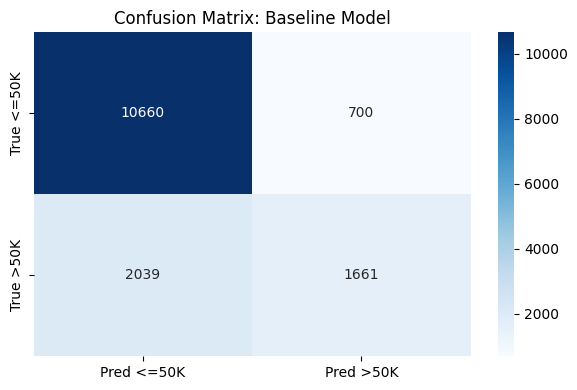

In [18]:
print('=== Classification Report (Overall) ===')
print(classification_report(y_test, y_pred_baseline,
                             target_names=['<=50K', '>50K']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred <=50K', 'Pred >50K'],
            yticklabels=['True <=50K', 'True >50K'])
plt.title('Confusion Matrix: Baseline Model')
plt.tight_layout()
plt.show()

## Step 4: Fairness Audit Evaluate by Subgroup

This is the core of the exercise. We use **Fairlearn's MetricFrame** to slice performance metrics across demographic groups.

### Key fairness metrics:
- **Accuracy by group**: Does the model perform equally well for everyone?
- **Selection rate**: Does the model predict >50K at the same rate across groups?
- **False Positive Rate**: Is one group incorrectly flagged as high-income more?
- **False Negative Rate**: Is one group incorrectly denied high-income prediction more?

In [19]:
# Evaluate by gender
metrics = {
    'accuracy':           accuracy_score,
    'selection_rate':     selection_rate,
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate,
}

mf_gender = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_baseline,
    sensitive_features=gender_test
)

print('=== Fairness Metrics by Gender ===')
print(mf_gender.by_group.round(4))
print(f'\nOverall accuracy: {mf_gender.overall["accuracy"]:.4f}')
print(f'Accuracy difference (max - min): {mf_gender.difference()["accuracy"]:.4f}')

=== Fairness Metrics by Gender ===
                     accuracy  selection_rate  false_positive_rate  \
sensitive_feature_0                                                  
Female                 0.8848          0.0625               0.0363   
Male                   0.7858          0.2024               0.0774   

                     false_negative_rate  
sensitive_feature_0                       
Female                            0.7325  
Male                              0.5189  

Overall accuracy: 0.8181
Accuracy difference (max - min): 0.0989


In [20]:
# Evaluate by race
mf_race = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_baseline,
    sensitive_features=race_test
)

print('=== Fairness Metrics by Race ===')
print(mf_race.by_group.round(4))
print(f'\nOverall accuracy: {mf_race.overall["accuracy"]:.4f}')
print(f'Accuracy difference (max - min): {mf_race.difference()["accuracy"]:.4f}')

=== Fairness Metrics by Race ===
                     accuracy  selection_rate  false_positive_rate  \
sensitive_feature_0                                                  
Amer-Indian-Eskimo     0.8926          0.0336               0.0077   
Asian-Pac-Islander     0.7917          0.1912               0.0732   
Black                  0.8944          0.0801               0.0378   
Other                  0.8443          0.1066               0.0408   
White                  0.8096          0.1659               0.0653   

                     false_negative_rate  
sensitive_feature_0                       
Amer-Indian-Eskimo                0.7895  
Asian-Pac-Islander                0.5289  
Black                             0.6071  
Other                             0.6250  
White                             0.5472  

Overall accuracy: 0.8181
Accuracy difference (max - min): 0.1027


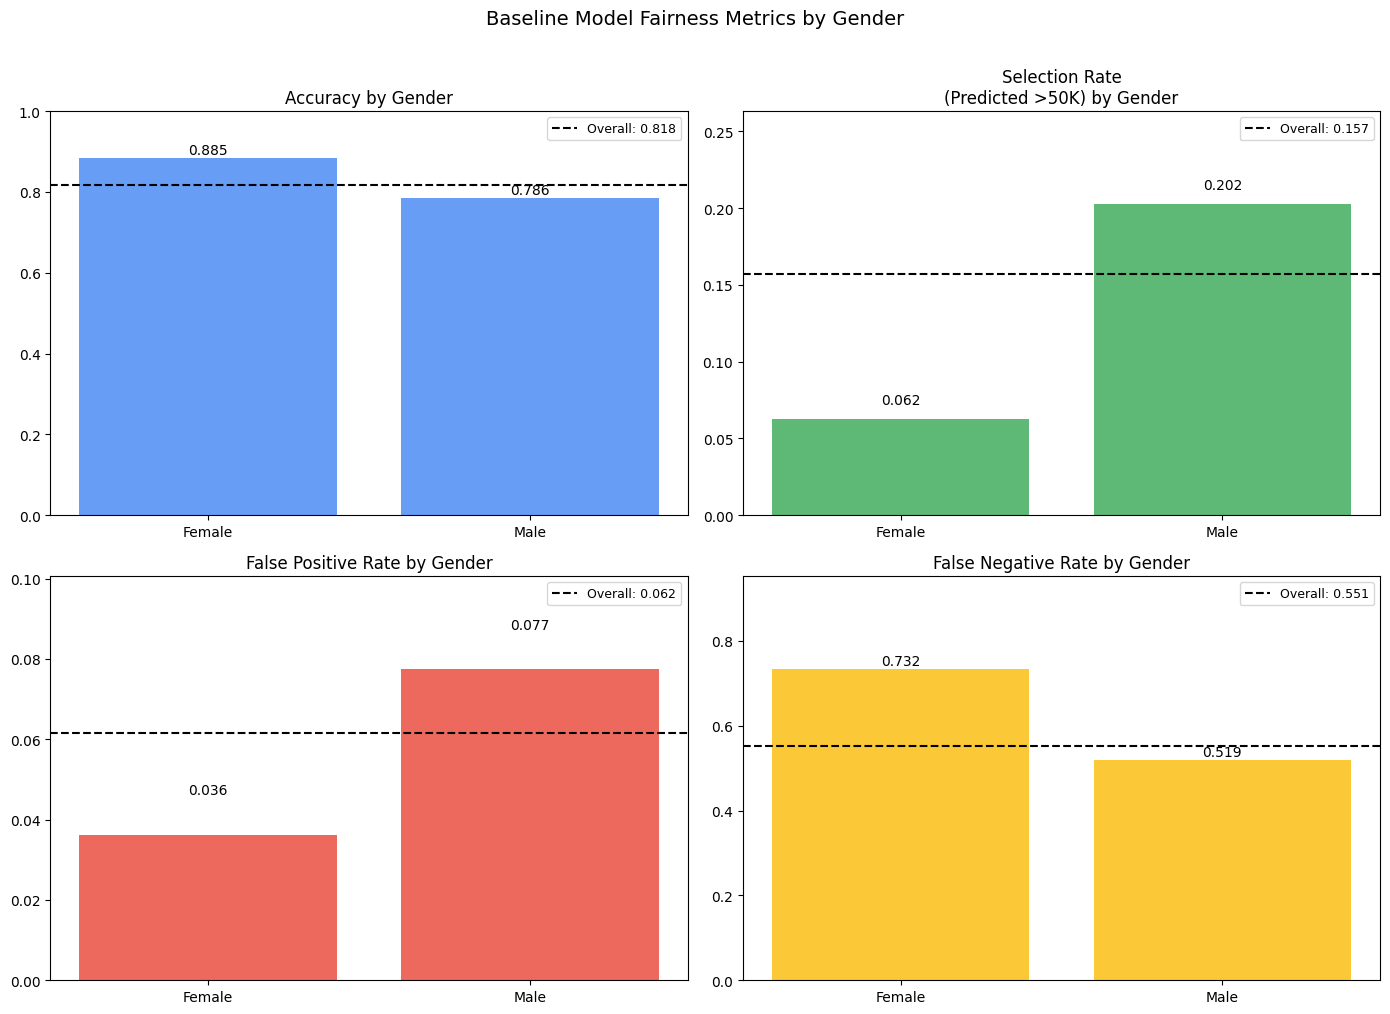

In [21]:
# Visualise subgroup metrics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_names = ['accuracy', 'selection_rate', 'false_positive_rate', 'false_negative_rate']
metric_labels = ['Accuracy', 'Selection Rate\n(Predicted >50K)', 'False Positive Rate', 'False Negative Rate']
colors = ['#4285F4', '#34A853', '#EA4335', '#FBBC05']

for ax, metric, label, color in zip(axes.flat, metric_names, metric_labels, colors):
    vals = mf_gender.by_group[metric]
    overall = mf_gender.overall[metric]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.8)
    ax.axhline(y=overall, color='black', linestyle='--',
               linewidth=1.5, label=f'Overall: {overall:.3f}')
    ax.set_title(f'{label} by Gender')
    ax.set_ylim(0, min(1.0, vals.max() * 1.3))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Baseline Model Fairness Metrics by Gender', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [27]:
# Summarise disparity scores
dpd = demographic_parity_difference(
    y_test, y_pred_baseline, sensitive_features=gender_test)
dpr = demographic_parity_ratio(
    y_test, y_pred_baseline, sensitive_features=gender_test)
eod = equalized_odds_difference(
    y_test, y_pred_baseline, sensitive_features=gender_test)

print('=== Disparity Summary (Gender) ===')
print(f'Demographic Parity Difference: {dpd:.4f}')
print(f'   Ideal = 0.0 (both groups predicted >50K at same rate)')
print(f'Demographic Parity Ratio:      {dpr:.4f}')
print(f'   Ideal = 1.0 (ratio of selection rates = 1)')
print(f'Equalized Odds Difference:     {eod:.4f}')
print(f'   Ideal = 0.0 (equal TPR and FPR across groups)')
print()
print("A large Demographic Parity Difference means the model predicts\nhigh income at very different rates for male vs female; even \nif that difference exists in the training data")


=== Disparity Summary (Gender) ===
Demographic Parity Difference: 0.1399
   Ideal = 0.0 (both groups predicted >50K at same rate)
Demographic Parity Ratio:      0.3087
   Ideal = 1.0 (ratio of selection rates = 1)
Equalized Odds Difference:     0.2136
   Ideal = 0.0 (equal TPR and FPR across groups)

A large Demographic Parity Difference means the model predicts
high income at very different rates for male vs female; even 
if that difference exists in the training data


# Bias Mitigation

Now that we've quantified the disparity, we apply **two mitigation approaches**:

1. **ExponentiatedGradient** (in-processing): modifies the training objective to penalize demographic disparity
2. **ThresholdOptimizer** (post-processing): adjusts decision thresholds per group after training



### ExponentiatedGradient with DemographicParity constraint

In [29]:
from sklearn.preprocessing import StandardScaler

# Scale features first (ExponentiatedGradient needs a plain estimator, not pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train fairness-constrained model
base_estimator = LogisticRegression(max_iter=1000, random_state=42)

mitigator_dp = ExponentiatedGradient(
    estimator=base_estimator,
    constraints=DemographicParity(),
    max_iter=50
)
mitigator_dp.fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_dp = mitigator_dp.predict(X_test_scaled)

print('ExponentiatedGradient (DemographicParity) trained.')
print(f'Overall Accuracy: {accuracy_score(y_test, y_pred_dp):.4f}')

ExponentiatedGradient (DemographicParity) trained.
Overall Accuracy: 0.7973


In [30]:
# Evaluate fairness after mitigation
mf_dp = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_dp,
    sensitive_features=gender_test
)

dpd_after = demographic_parity_difference(
    y_test, y_pred_dp, sensitive_features=gender_test)
eod_after = equalized_odds_difference(
    y_test, y_pred_dp, sensitive_features=gender_test)

print('=== After Mitigation (DemographicParity) ===')
print(mf_dp.by_group.round(4))
print(f'\nDemographic Parity Difference: {dpd_after:.4f} (was {dpd:.4f})')
print(f'Equalized Odds Difference:     {eod_after:.4f} (was {eod:.4f})')

=== After Mitigation (DemographicParity) ===
                     accuracy  selection_rate  false_positive_rate  \
sensitive_feature_0                                                  
Female                 0.8760          0.1242               0.0760   
Male                   0.7592          0.1307               0.0447   

                     false_negative_rate  
sensitive_feature_0                       
Female                            0.4991  
Male                              0.6777  

Demographic Parity Difference: 0.0065 (was 0.1399)
Equalized Odds Difference:     0.1786 (was 0.2136)


###  ThresholdOptimizer with EqualizedOdds constraint

In [31]:
postprocess_model = ThresholdOptimizer(
    estimator=baseline_model,
    constraints='equalized_odds',
    objective='balanced_accuracy_score',
    predict_method='predict_proba',
    prefit=True
)
postprocess_model.fit(X_train, y_train, sensitive_features=gender_train)
y_pred_pp = postprocess_model.predict(X_test, sensitive_features=gender_test)

mf_pp = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_pp,
    sensitive_features=gender_test
)

dpd_pp = demographic_parity_difference(
    y_test, y_pred_pp, sensitive_features=gender_test)
eod_pp = equalized_odds_difference(
    y_test, y_pred_pp, sensitive_features=gender_test)

print('=== After ThresholdOptimizer (EqualizedOdds) ===')
print(mf_pp.by_group.round(4))
print(f'\nDemographic Parity Difference: {dpd_pp:.4f} (was {dpd:.4f})')
print(f'Equalized Odds Difference:     {eod_pp:.4f} (was {eod:.4f})')

=== After ThresholdOptimizer (EqualizedOdds) ===
                     accuracy  selection_rate  false_positive_rate  \
sensitive_feature_0                                                  
Female                 0.7588          0.2495               0.2128   
Male                   0.7103          0.2975               0.2010   

                     false_negative_rate  
sensitive_feature_0                       
Female                            0.4632  
Male                              0.4874  

Demographic Parity Difference: 0.0480 (was 0.1399)
Equalized Odds Difference:     0.0242 (was 0.2136)


##  Compare All Models Side by Side

The classic **accuracy fairness tradeoff**: mitigation usually costs some overall accuracy in exchange for reduced disparity. The right balance depends on your use case.

In [32]:
results = pd.DataFrame({
    'Model': ['Baseline', 'ExponentiatedGradient\n(DemographicParity)', 'ThresholdOptimizer\n(EqualizedOdds)'],
    'Overall Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_dp),
        accuracy_score(y_test, y_pred_pp)
    ],
    'Demographic Parity Diff': [dpd, dpd_after, dpd_pp],
    'Equalized Odds Diff': [eod, eod_after, eod_pp],
    'Female Selection Rate': [
        mf_gender.by_group['selection_rate']['Female'],
        mf_dp.by_group['selection_rate']['Female'],
        mf_pp.by_group['selection_rate']['Female']
    ],
    'Male Selection Rate': [
        mf_gender.by_group['selection_rate']['Male'],
        mf_dp.by_group['selection_rate']['Male'],
        mf_pp.by_group['selection_rate']['Male']
    ],
})

print('=== Model Comparison ===')
print(results.set_index('Model').round(4).to_string())

=== Model Comparison ===
                                            Overall Accuracy  Demographic Parity Diff  Equalized Odds Diff  Female Selection Rate  Male Selection Rate
Model                                                                                                                                                 
Baseline                                              0.8181                   0.1399               0.2136                 0.0625               0.2024
ExponentiatedGradient\n(DemographicParity)            0.7973                   0.0065               0.1786                 0.1242               0.1307
ThresholdOptimizer\n(EqualizedOdds)                   0.7261                   0.0480               0.0242                 0.2495               0.2975


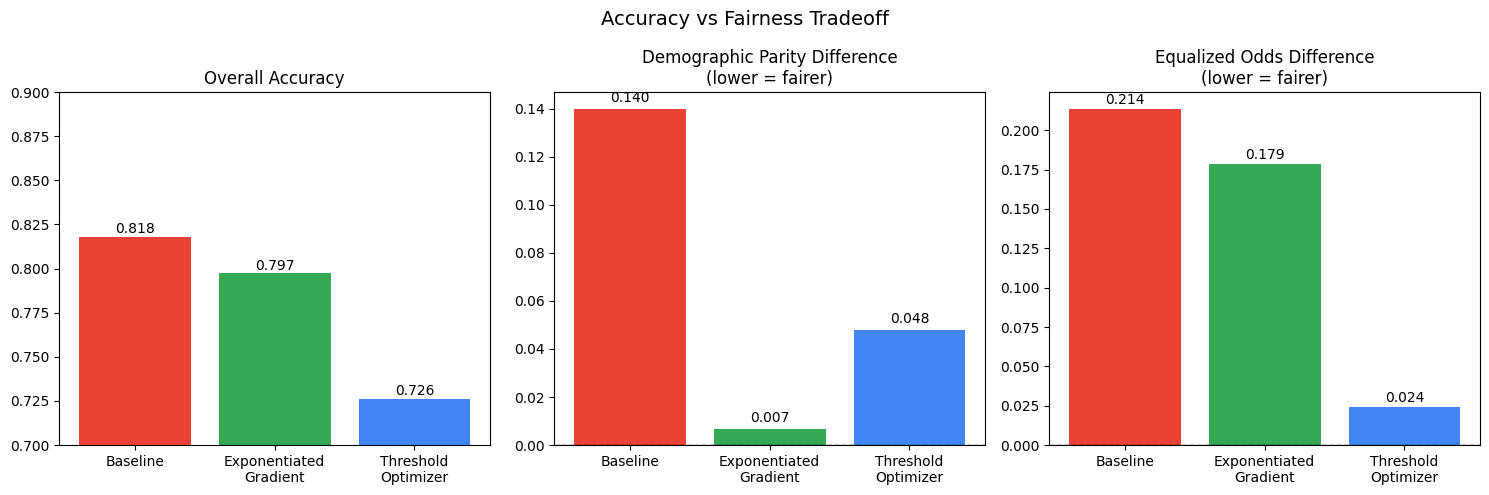

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = ['Baseline', 'Exponentiated\nGradient', 'Threshold\nOptimizer']
bar_colors = ['#EA4335', '#34A853', '#4285F4']

# Overall accuracy
axes[0].bar(model_names, results['Overall Accuracy'], color=bar_colors)
axes[0].set_title('Overall Accuracy')
axes[0].set_ylim(0.7, 0.9)
for i, v in enumerate(results['Overall Accuracy']):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center')

# Demographic parity difference
axes[1].bar(model_names, results['Demographic Parity Diff'], color=bar_colors)
axes[1].set_title('Demographic Parity Difference\n(lower = fairer)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(results['Demographic Parity Diff']):
    axes[1].text(i, v + 0.003, f'{v:.3f}', ha='center')

# Equalized odds difference
axes[2].bar(model_names, results['Equalized Odds Diff'], color=bar_colors)
axes[2].set_title('Equalized Odds Difference\n(lower = fairer)')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(results['Equalized Odds Diff']):
    axes[2].text(i, v + 0.003, f'{v:.3f}', ha='center')

plt.suptitle('Accuracy vs Fairness Tradeoff', fontsize=14)
plt.tight_layout()
plt.show()

## Reflection Questions

These mirror the discussion questions in Google's original exercise:

**1. Data exploration**
- What did i notice about the income distribution by gender and race?
- Why might a model trained on this data produce unfair outcomes even without using gender/race as features directly?

**2. Subgroup evaluation**
- Which group had the lowest accuracy? Which had the highest false negative rate?
- What is the real-world impact of a high false negative rate for a disadvantaged group in an income prediction context?

**3. Fairness metrics**
- Demographic Parity says: *predict the same rate of >50K across groups*. Is this always the right metric?
- Equalized Odds says: *have equal TPR and FPR across groups*. When might you prefer this over Demographic Parity?
- Can a model satisfy both simultaneously? (Hint: look up [impossibility theorems in fairness](https://arxiv.org/abs/1609.07236))

**4. Mitigation tradeoffs**
- How much accuracy did each mitigation approach sacrifice?
- In a real loan approval or hiring system, how would you weigh that tradeoff?
- Does removing gender from features fully prevent gender bias? Why or why not?

**5. Broader context**
- The dataset is from 1994. How might that affect the model's relevance today?
- What other subgroups (beyond gender and race) might be worth auditing?

---

### Summary

| Concept | What i did |
|---|---|
| Data exploration | Identified demographic imbalances before training |
| Baseline training | Trained a model with good overall accuracy |
| Subgroup evaluation | Used MetricFrame to slice metrics by gender and race |
| Fairness metrics | Computed Demographic Parity and Equalized Odds disparities |
| Bias mitigation | Applied ExponentiatedGradient and ThresholdOptimizer |
| Tradeoff analysis | Compared accuracy vs fairness across all three models |

**Next steps:** I can try auditing by `race` instead of `gender` in the mitigation step, or combine both as a multi-attribute sensitive feature using `sensitive_features=pd.DataFrame({'gender': gender_test, 'race': race_test})`.

In [2]:
!find /content -name "*.ipynb" 2>/dev/null
!find /root -name "*.ipynb" 2>/dev/null

/root/.julia/packages/Interpolations/dR5oF/doc/Interpolations.jl.ipynb
/root/.julia/packages/Interpolations/dR5oF/doc/Plotting examples.ipynb


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
